In [26]:
#  TASK 2 — KMeans Clustering + Elbow + Silhouette
#  Credit Card Customer Segmentation
#  NOTE: Run Task 1 first — this file continues from its pipeline
# ================================================================
 
# ── STEP 0: Install & Import ─────────────────────────────────────
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
 
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (silhouette_score, silhouette_samples,
                              davies_bouldin_score, calinski_harabasz_score)
from scipy.spatial.distance import cdist
import joblib


In [28]:
import warnings
warnings.filterwarnings('ignore')
 
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize']    = (14, 5)
plt.rcParams['axes.titlesize']    = 13
plt.rcParams['axes.titleweight']  = 'bold'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
 
print(" Libraries loaded!")

 Libraries loaded!


In [32]:
 df = pd.read_csv('CC GENERAL (1).csv')
 
# ── Imputation (نفس Task 1) ──────────────────────────────────────
df.dropna(subset=['CREDIT_LIMIT'], inplace=True)
 
df.loc[
    df['MINIMUM_PAYMENTS'].isna() & (df['BALANCE'] == 0),
    'MINIMUM_PAYMENTS'
] = 0
 
ratio = (
    df.loc[df['MINIMUM_PAYMENTS'].notnull(), 'MINIMUM_PAYMENTS'].median()
    /
    df.loc[df['BALANCE'].notnull(), 'BALANCE'].median()
)
mask = df['MINIMUM_PAYMENTS'].isna() & (df['BALANCE'] > 0)
df.loc[mask, 'MINIMUM_PAYMENTS'] = ratio * df.loc[mask, 'BALANCE']

In [34]:
df['uses_cash_advance']    = (df['CASH_ADVANCE'] > 0).astype(int)
df['TOTAL_SPEND']          = df['PURCHASES'] + df['CASH_ADVANCE']
df['CREDIT_UTILIZATION']   = df['BALANCE'] / (df['CREDIT_LIMIT'] + 1)
df['CASH_DEPENDENCY']      = df['CASH_ADVANCE'] / (df['TOTAL_SPEND'] + 1)
df['PAYMENT_EFFICIENCY']   = df['PAYMENTS'] / (df['BALANCE'] + 1)
df['PURCHASE_INTENSITY']   = df['PURCHASES'] / (df['TENURE'] + 1)
df['INSTALLMENT_RATIO']    = df['INSTALLMENTS_PURCHASES'] / (df['PURCHASES'] + 1)
df['ONEOFF_RATIO']         = df['ONEOFF_PURCHASES'] / (df['PURCHASES'] + 1)
df['IS_ACTIVE']            = ((df['PURCHASES'] > 0) | (df['CASH_ADVANCE'] > 0)).astype(int)
df['IS_INACTIVE']          = ((df['PURCHASES'] == 0) & (df['CASH_ADVANCE'] == 0)).astype(int)
df['IS_FULL_PAYER']        = (df['PRC_FULL_PAYMENT'] > 0.5).astype(int)
df['DEBT_PRESSURE']        = df['MINIMUM_PAYMENTS'] / (df['BALANCE'] + 1)
df['TOTAL_TRANSACTIONS']   = df['PURCHASES_TRX'] + df['CASH_ADVANCE_TRX']
 
df.replace([np.inf, -np.inf], 0, inplace=True)
df.fillna(0, inplace=True)
 
df_model = df.drop(columns=['CUST_ID'])

In [38]:
# ── Log Transform + Scaling + PCA 
X_log    = np.log1p(df_model)
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_log)
X_scaled = pd.DataFrame(X_scaled, columns=df_model.columns)
 
pca      = PCA(n_components=0.9, random_state=42)
X_pca    = pca.fit_transform(X_scaled)
 
pca_2d   = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)
 
print(f" Pipeline rebuilt:")
print(f"   Rows            : {df_model.shape[0]:,}")
print(f"   Features        : {df_model.shape[1]}")
print(f"   After PCA (90%) : {X_pca.shape[1]} components")
print(f"   Explained var   : {np.sum(pca.explained_variance_ratio_):.4f}")
 

 Pipeline rebuilt:
   Rows            : 8,949
   Features        : 30
   After PCA (90%) : 10 components
   Explained var   : 0.9189



 Elbow Method (k = 2 → 12)...
  k= 2  WCSS=181,676.69
  k= 3  WCSS=151,644.01
  k= 4  WCSS=133,706.23
  k= 5  WCSS=117,954.80
  k= 6  WCSS=105,110.53
  k= 7  WCSS=96,440.35
  k= 8  WCSS=88,543.81
  k= 9  WCSS=83,007.42
  k=10  WCSS=77,783.37
  k=11  WCSS=74,131.32
  k=12  WCSS=70,587.41

 Elbow detected at k = 3


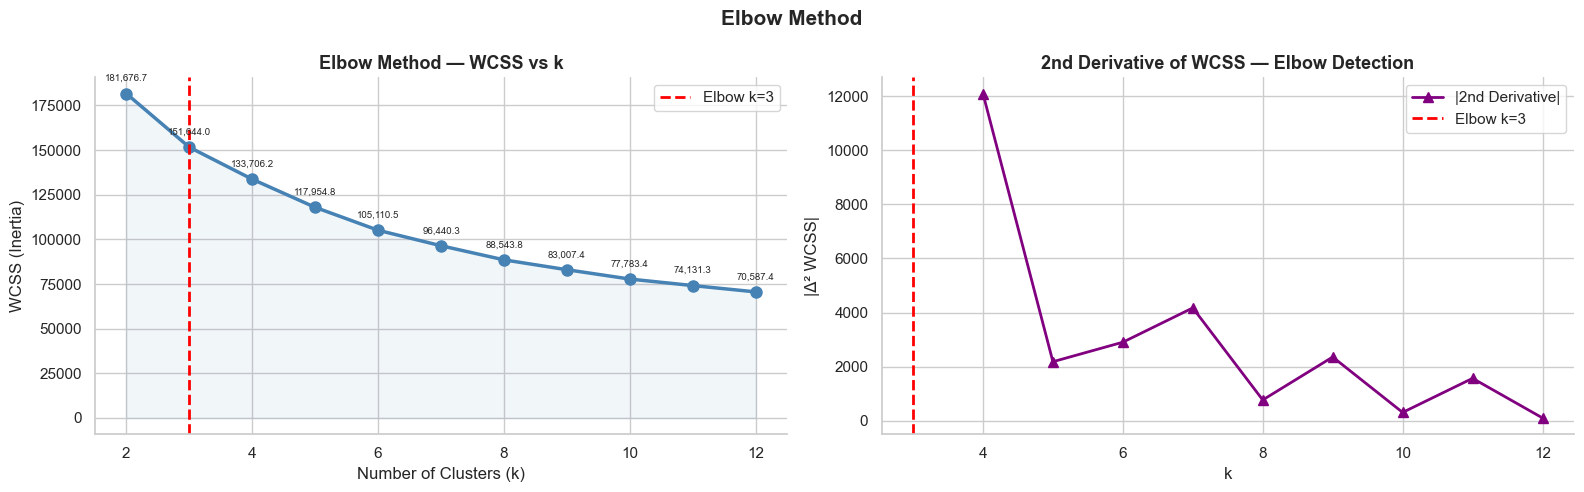

In [41]:
#  STEP 2: Elbow Method — WCSS
# ================================================================
print("\n Elbow Method (k = 2 → 12)...")
 
K_range = range(2, 13)
wcss    = []
 
for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=20,
                max_iter=500, random_state=42)
    km.fit(X_pca)
    wcss.append(km.inertia_)
    print(f"  k={k:2d}  WCSS={km.inertia_:,.2f}")
 
wcss_arr    = np.array(wcss)
second_diff = np.diff(np.diff(wcss_arr))
elbow_k     = list(K_range)[np.argmax(np.abs(second_diff)) + 1]
print(f"\n Elbow detected at k = {elbow_k}")
 
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
 
axes[0].plot(list(K_range), wcss, 'o-', color='steelblue',
             linewidth=2.5, markersize=8)
axes[0].axvline(elbow_k, color='red', linestyle='--',
                linewidth=2, label=f'Elbow k={elbow_k}')
axes[0].fill_between(list(K_range), wcss, alpha=0.07, color='steelblue')
for k, w in zip(K_range, wcss):
    axes[0].annotate(f'{w:,.1f}', (k, w),
                     textcoords='offset points', xytext=(0, 9),
                     ha='center', fontsize=7)
axes[0].set_title('Elbow Method — WCSS vs k')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('WCSS (Inertia)')
axes[0].legend()
 
axes[1].plot(list(K_range)[2:], np.abs(second_diff), '^-',
             color='purple', linewidth=2, markersize=7,
             label='|2nd Derivative|')
axes[1].axvline(elbow_k, color='red', linestyle='--',
                linewidth=2, label=f'Elbow k={elbow_k}')
axes[1].set_title('2nd Derivative of WCSS — Elbow Detection')
axes[1].set_xlabel('k')
axes[1].set_ylabel('|Δ² WCSS|')
axes[1].legend()
 
plt.suptitle('Elbow Method', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
 


 Computing evaluation metrics...
  k= 2  Silhouette=0.2807  DB=1.4466  CH=3201.9
  k= 3  Silhouette=0.2565  DB=1.5175  CH=2803.7
  k= 4  Silhouette=0.2627  DB=1.1405  CH=2519.7
  k= 5  Silhouette=0.2368  DB=1.2569  CH=2440.4
  k= 6  Silhouette=0.2529  DB=1.1588  CH=2409.2
  k= 7  Silhouette=0.2504  DB=1.1430  CH=2321.9
  k= 8  Silhouette=0.2445  DB=1.1301  CH=2281.4
  k= 9  Silhouette=0.2572  DB=1.1178  CH=2203.7
  k=10  Silhouette=0.2539  DB=1.1822  CH=2156.8
  k=11  Silhouette=0.2568  DB=1.2582  CH=2080.6
  k=12  Silhouette=0.2298  DB=1.2407  CH=2027.0

 Best k — Silhouette        : 2  (0.2807)
 Best k — Davies-Bouldin   : 9  (1.1178)
 Best k — Calinski-Harabasz: 2  (3201.9)


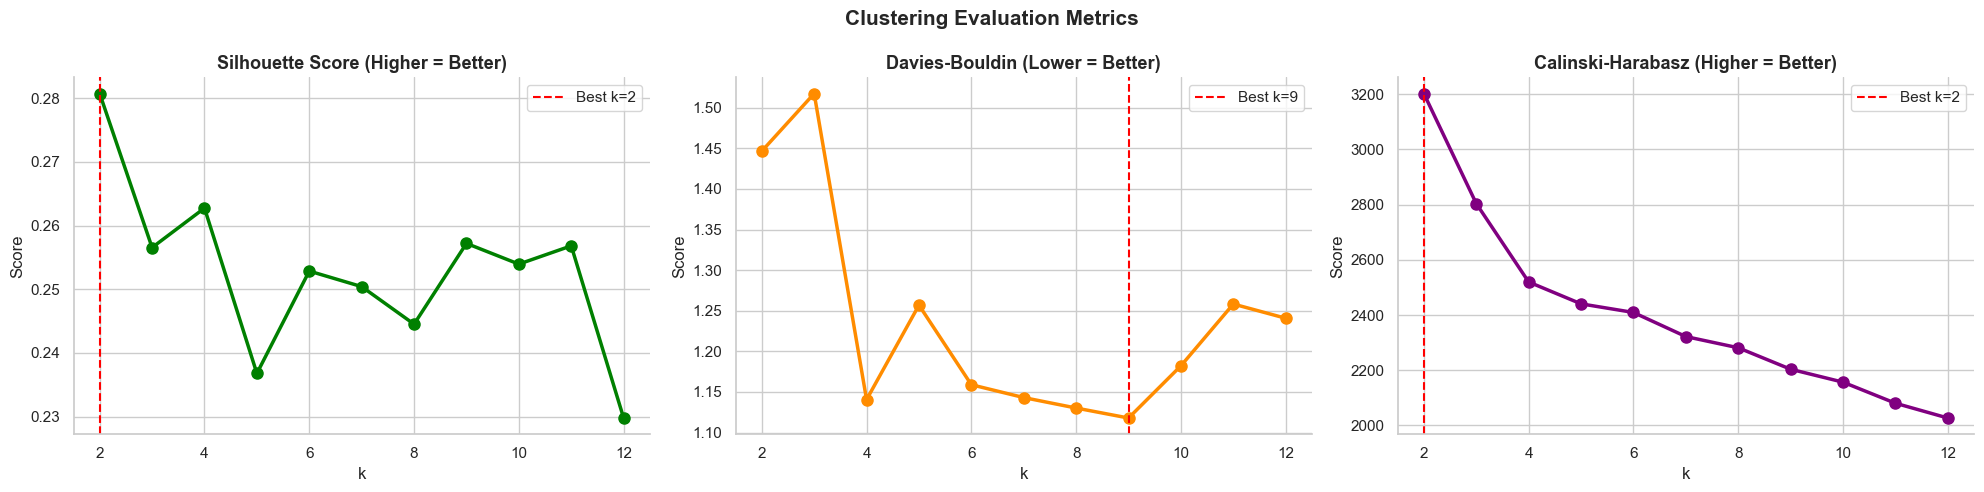

In [45]:
# STEP 3: Evaluation Metrics — Silhouette + DB + CH
# ================================================================
print("\n Computing evaluation metrics...")

sil_scores = []
db_scores  = []
ch_scores  = []

for k in K_range:
    km     = KMeans(n_clusters=k, init='k-means++', n_init=20, 
                    max_iter=500, random_state=42)
    labels = km.fit_predict(X_pca)
    
    
    score = silhouette_score(X_pca, labels, sample_size=1000, random_state=42)
    sil_scores.append(score)
    
    db_scores.append(davies_bouldin_score(X_pca, labels))
    ch_scores.append(calinski_harabasz_score(X_pca, labels))
    
    print(f"  k={k:2d}  Silhouette={sil_scores[-1]:.4f}  "
          f"DB={db_scores[-1]:.4f}  CH={ch_scores[-1]:.1f}")

best_sil_k = list(K_range)[np.argmax(sil_scores)]
best_db_k  = list(K_range)[np.argmin(db_scores)]
best_ch_k  = list(K_range)[np.argmax(ch_scores)]

print(f"\n Best k — Silhouette        : {best_sil_k}  ({max(sil_scores):.4f})")
print(f" Best k — Davies-Bouldin   : {best_db_k}  ({min(db_scores):.4f})")
print(f" Best k — Calinski-Harabasz: {best_ch_k}  ({max(ch_scores):.1f})")

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].plot(list(K_range), sil_scores, 'o-', color='green', linewidth=2.5, markersize=8)
axes[0].axvline(best_sil_k, color='red', linestyle='--', label=f'Best k={best_sil_k}')
axes[0].set_title('Silhouette Score (Higher = Better)')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Score'); axes[0].legend()

axes[1].plot(list(K_range), db_scores, 'o-', color='darkorange', linewidth=2.5, markersize=8)
axes[1].axvline(best_db_k, color='red', linestyle='--', label=f'Best k={best_db_k}')
axes[1].set_title('Davies-Bouldin (Lower = Better)')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Score'); axes[1].legend()

axes[2].plot(list(K_range), ch_scores, 'o-', color='purple', linewidth=2.5, markersize=8)
axes[2].axvline(best_ch_k, color='red', linestyle='--', label=f'Best k={best_ch_k}')
axes[2].set_title('Calinski-Harabasz (Higher = Better)')
axes[2].set_xlabel('k'); axes[2].set_ylabel('Score'); axes[2].legend()

plt.suptitle('Clustering Evaluation Metrics', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [71]:
#  STEP 4: Voting — Final k
# ================================================================
votes = {}
for k in [elbow_k, best_sil_k, best_db_k, best_ch_k]:
    votes[k] = votes.get(k, 0) + 1
 
print("\n  VOTING SUMMARY:")
for k, v in sorted(votes.items()):
    marker = " access" if v == max(votes.values()) else ""
    print(f"   k={k} → {v} vote(s){marker}")
 
final_k = max(votes, key=votes.get)
# Override لو k=2 عشان نضمن segmentation أغنى
if final_k == 2:
    final_k = 3
    print("  k overridden to 3 for richer segmentation")
print(f"\n Final k = {final_k}")
 
kmeans = KMeans(n_clusters=final_k, init='k-means++',
                n_init=50, max_iter=1000, random_state=42)
labels = kmeans.fit_predict(X_pca)
 


  VOTING SUMMARY:
   k=2 → 2 vote(s) access
   k=3 → 1 vote(s)
   k=9 → 1 vote(s)
  k overridden to 3 for richer segmentation

 Final k = 3


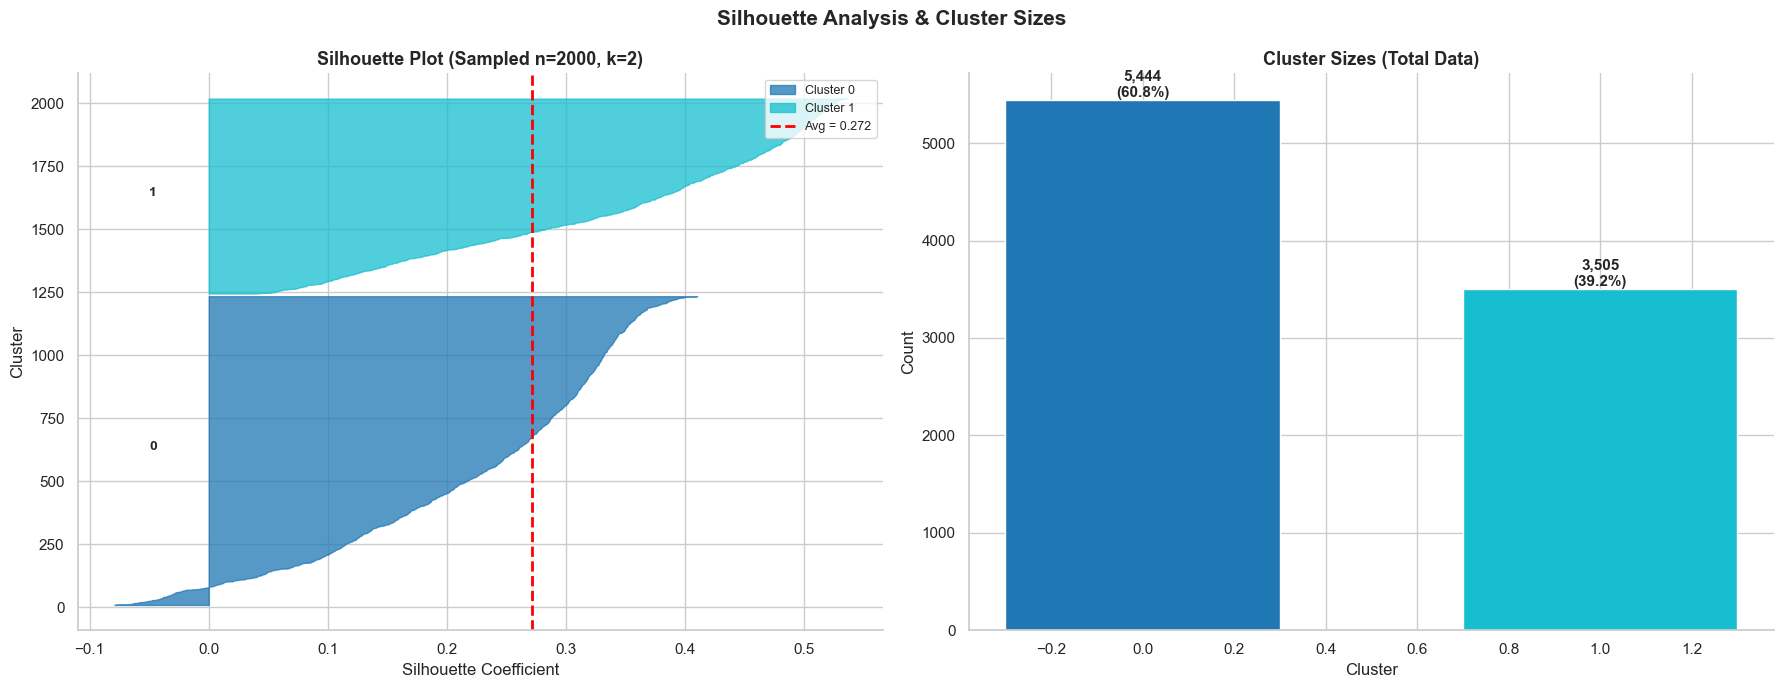

In [53]:
#  STEP 5: Silhouette Plot per Sample (Fixed with Sampling)
# ================================================================
import numpy as np

if len(X_pca) > 2000:
    indices = np.random.choice(len(X_pca), 2000, replace=False)
    X_sample = X_pca[indices]
    labels_sample = labels[indices]
else:
    X_sample = X_pca
    labels_sample = labels

sample_sil = silhouette_samples(X_sample, labels_sample)
avg_sil    = silhouette_score(X_sample, labels_sample)
cmap       = plt.cm.get_cmap('tab10', final_k)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

y_lower = 10
for i in range(final_k):
    vals    = np.sort(sample_sil[labels_sample == i])
    y_upper = y_lower + len(vals)
    
    axes[0].fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                          alpha=0.75, color=cmap(i), label=f'Cluster {i}')
    axes[0].text(-0.05, y_lower + len(vals)/2, str(i),
                 fontsize=10, fontweight='bold')
    y_lower = y_upper + 10

axes[0].axvline(avg_sil, color='red', linestyle='--', linewidth=2,
                label=f'Avg = {avg_sil:.3f}')
axes[0].set_title(f'Silhouette Plot (Sampled n=2000, k={final_k})')
axes[0].set_xlabel('Silhouette Coefficient')
axes[0].set_ylabel('Cluster')
axes[0].legend(fontsize=9)

sizes = pd.Series(labels).value_counts().sort_index()
bars  = axes[1].bar(sizes.index, sizes.values,
                     color=[cmap(i) for i in range(final_k)],
                     edgecolor='white', width=0.6)

for bar, val in zip(bars, sizes.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 30,
                 f'{val:,}\n({val/len(labels)*100:.1f}%)',
                 ha='center', fontsize=11, fontweight='bold')

axes[1].set_title('Cluster Sizes (Total Data)')
axes[1].set_xlabel('Cluster'); axes[1].set_ylabel('Count')

plt.suptitle('Silhouette Analysis & Cluster Sizes', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


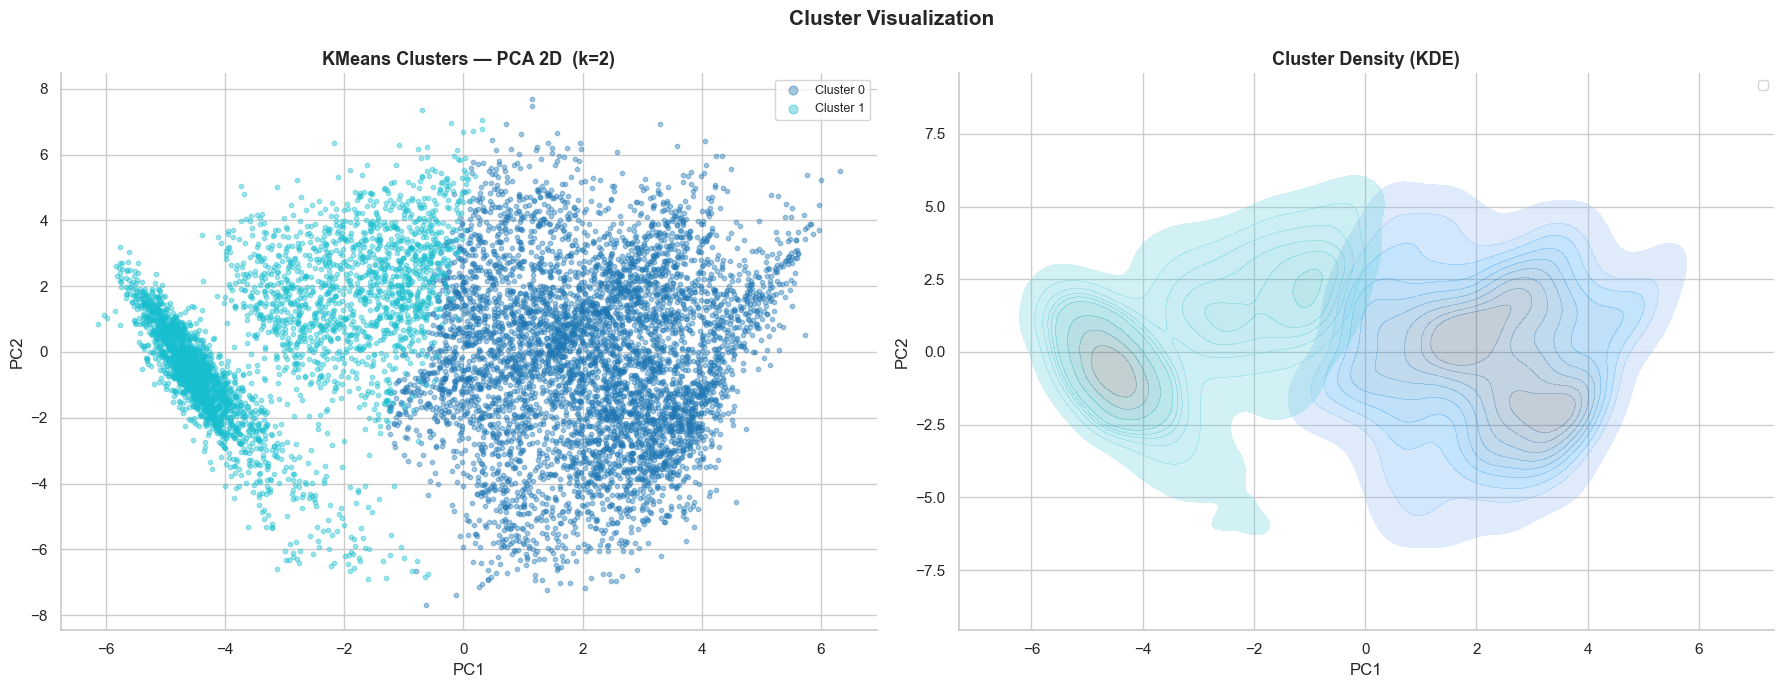

In [55]:
#  STEP 6: Cluster Visualization — PCA 2D
# ================================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
 
for i in range(final_k):
    mask = labels == i
    axes[0].scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                    s=10, alpha=0.4, color=cmap(i), label=f'Cluster {i}')
 
axes[0].set_title(f'KMeans Clusters — PCA 2D  (k={final_k})')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend(markerscale=2, fontsize=9)
 
for i in range(final_k):
    mask = labels == i
    sns.kdeplot(x=X_pca_2d[mask, 0], y=X_pca_2d[mask, 1],
                ax=axes[1], fill=True, alpha=0.3,
                color=cmap(i), label=f'Cluster {i}')
axes[1].set_title('Cluster Density (KDE)')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].legend(fontsize=9)
 
plt.suptitle('Cluster Visualization', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


 CLUSTER PROFILES:
Cluster                                  0         1
BALANCE                            980.800  2471.486
BALANCE_FREQUENCY                    0.855     0.912
PURCHASES                         1488.688   249.434
ONEOFF_PURCHASES                   863.688   171.298
INSTALLMENTS_PURCHASES             625.417    78.256
CASH_ADVANCE                       163.609  2245.369
PURCHASES_FREQUENCY                  0.693     0.176
ONEOFF_PURCHASES_FREQUENCY           0.280     0.083
PURCHASES_INSTALLMENTS_FREQUENCY     0.534     0.102
CASH_ADVANCE_FREQUENCY               0.028     0.301
CASH_ADVANCE_TRX                     0.595     7.371
PURCHASES_TRX                       21.811     3.685
CREDIT_LIMIT                      4540.027  4423.658
PAYMENTS                          1639.772  1878.661
MINIMUM_PAYMENTS                   669.226  1107.614
PRC_FULL_PAYMENT                     0.228     0.038
TENURE                              11.644    11.322
uses_cash_advance         

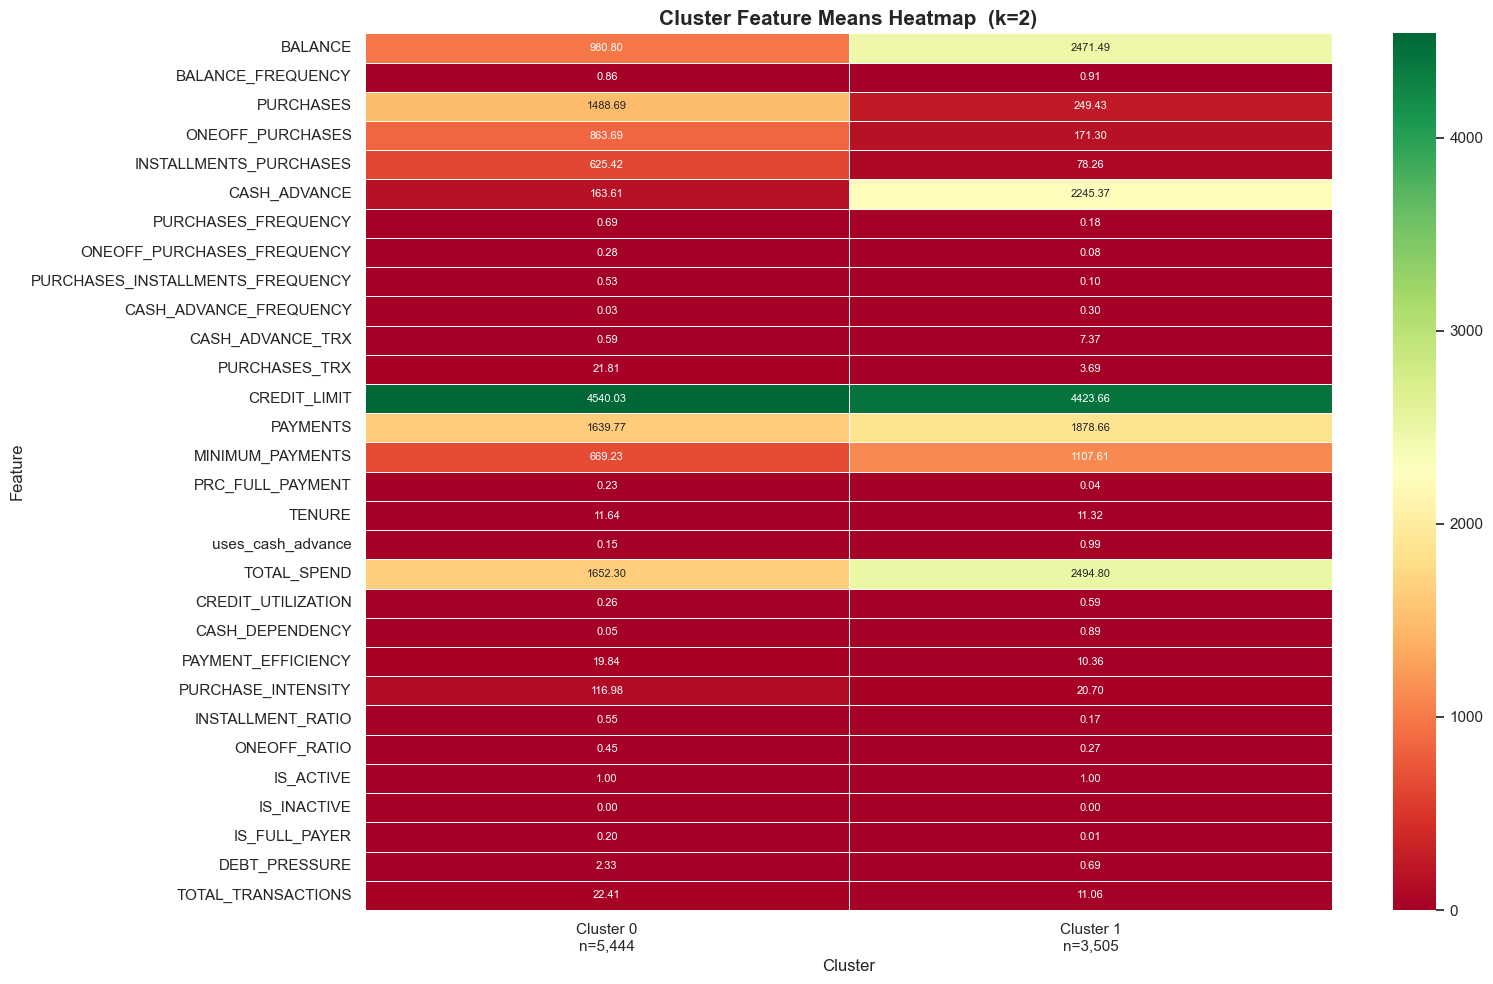

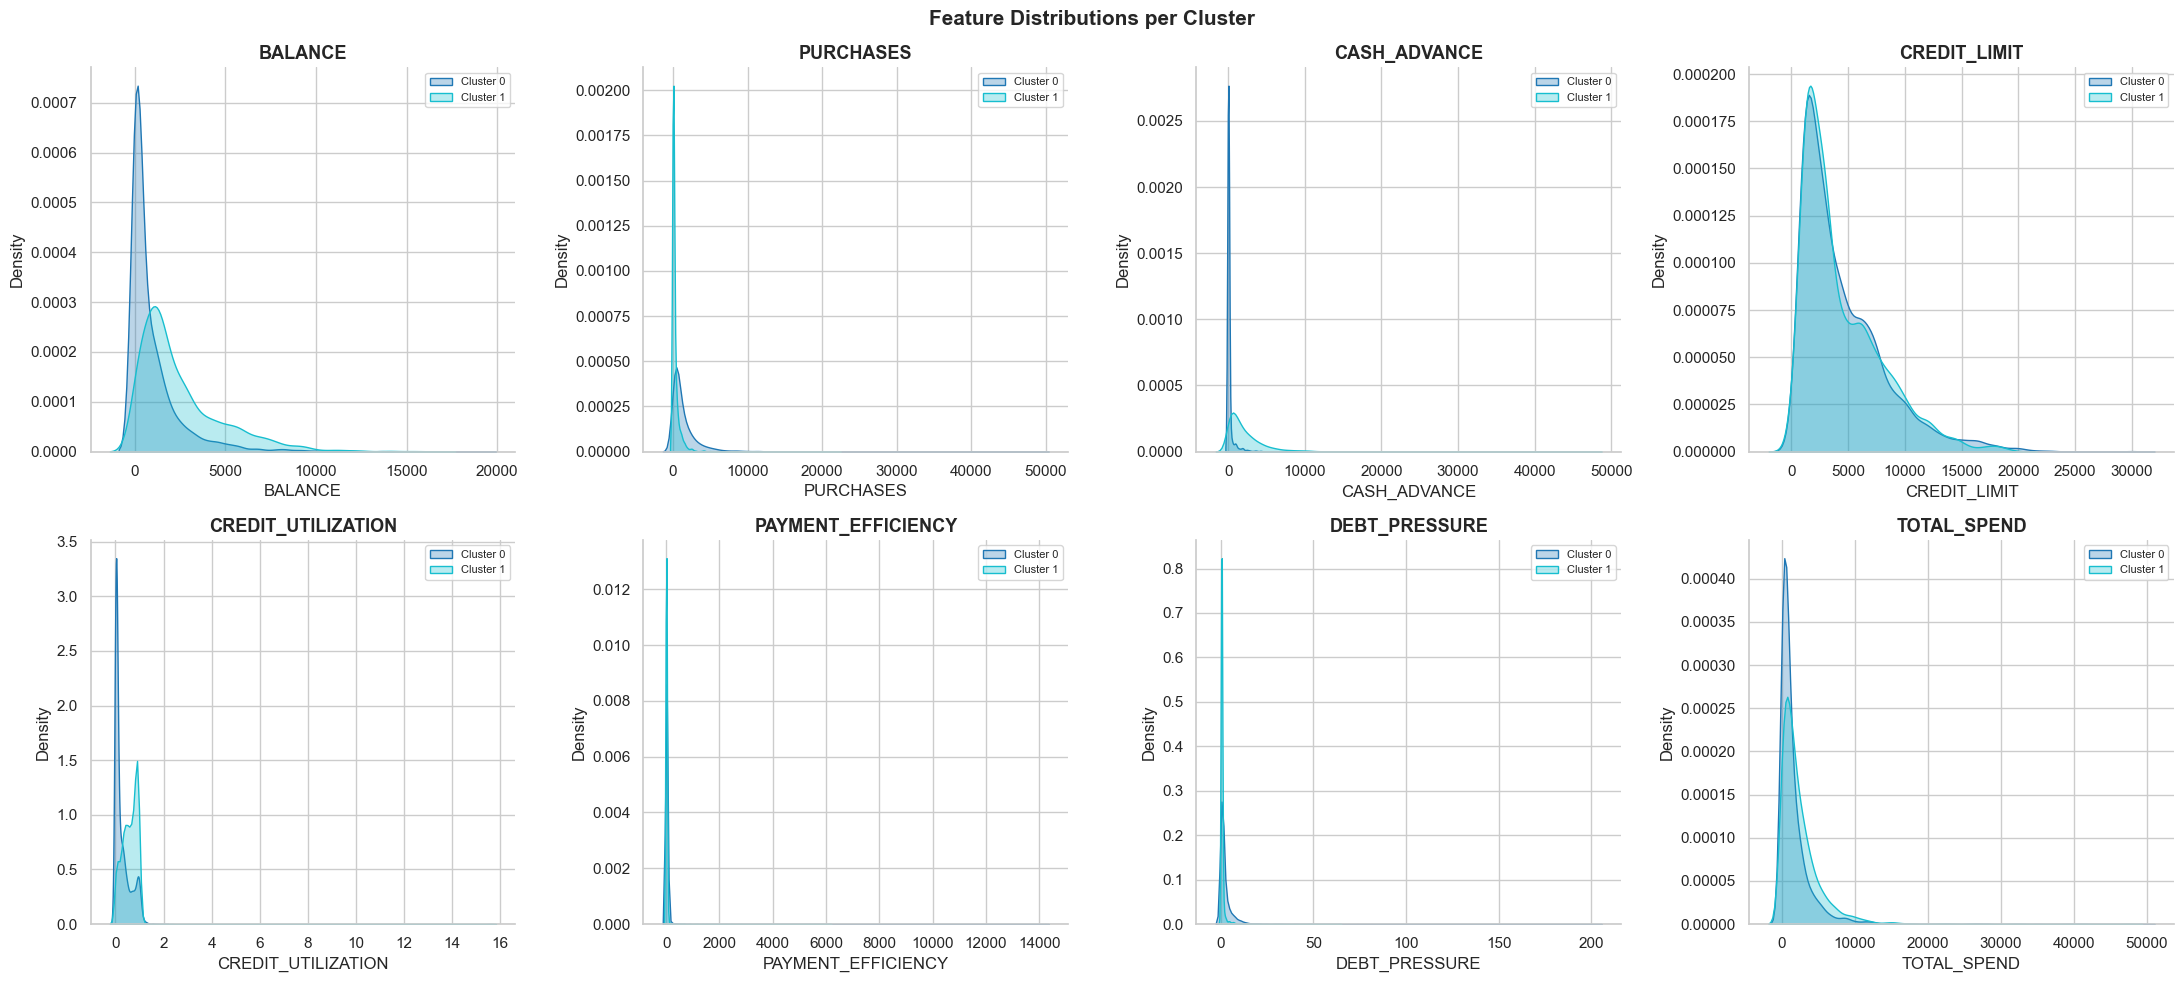

In [59]:
#  STEP 7: Cluster Profiling — Heatmap + KDE
# ================================================================
df_profile            = df_model.copy()
df_profile['Cluster'] = labels
cluster_means         = df_profile.groupby('Cluster').mean()
cluster_count         = df_profile.groupby('Cluster').size()
 
print("\n CLUSTER PROFILES:")
print(cluster_means.T.round(3).to_string())
 
plt.figure(figsize=(16, 10))
sns.heatmap(
    cluster_means.T, annot=True, fmt='.2f', cmap='RdYlGn',
    linewidths=0.5, annot_kws={'size': 8},
    xticklabels=[f'Cluster {i}\nn={cluster_count[i]:,}'
                 for i in range(final_k)]
)
plt.title(f'Cluster Feature Means Heatmap  (k={final_k})',
          fontsize=15, fontweight='bold')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()
 
top_feats = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT',
             'CREDIT_UTILIZATION', 'PAYMENT_EFFICIENCY',
             'DEBT_PRESSURE', 'TOTAL_SPEND']
 
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()
for idx, feat in enumerate(top_feats):
    for i in range(final_k):
        sns.kdeplot(df_profile.loc[labels == i, feat],
                    ax=axes[idx], fill=True, alpha=0.3,
                    color=cmap(i), label=f'Cluster {i}')
    axes[idx].set_title(feat)
    axes[idx].legend(fontsize=8)
 
plt.suptitle('Feature Distributions per Cluster',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

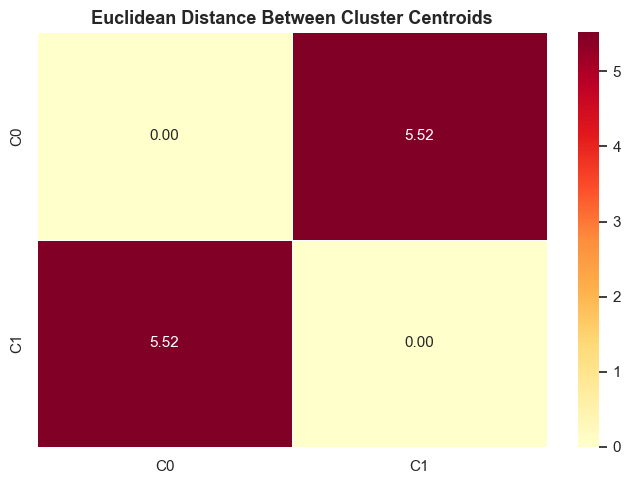

In [61]:
#  STEP 8: Centroid Distance Matrix
# ================================================================
dist_matrix = cdist(kmeans.cluster_centers_,
                     kmeans.cluster_centers_, metric='euclidean')
dist_df     = pd.DataFrame(
    dist_matrix,
    index=[f'C{i}' for i in range(final_k)],
    columns=[f'C{i}' for i in range(final_k)]
)
 
plt.figure(figsize=(7, 5))
sns.heatmap(dist_df, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, annot_kws={'size': 11})
plt.title('Euclidean Distance Between Cluster Centroids', fontweight='bold')
plt.tight_layout()
plt.show()
 

In [63]:
#  STEP 9: Cluster Interpretation
# ================================================================
print("\n CLUSTER INTERPRETATION:")
print("=" * 60)
 
interp_feats = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE',
                'CREDIT_UTILIZATION', 'PAYMENT_EFFICIENCY',
                'DEBT_PRESSURE', 'IS_ACTIVE', 'IS_FULL_PAYER']
 
for i in range(final_k):
    row = cluster_means.loc[i, interp_feats]
    print(f"\n  Cluster {i}  (n={cluster_count[i]:,} — {cluster_count[i]/len(labels)*100:.1f}%)")
    print(f"    Balance             : {row['BALANCE']:.2f}")
    print(f"    Purchases           : {row['PURCHASES']:.2f}")
    print(f"    Cash Advance        : {row['CASH_ADVANCE']:.2f}")
    print(f"    Credit Utilization  : {row['CREDIT_UTILIZATION']:.2f}")
    print(f"    Payment Efficiency  : {row['PAYMENT_EFFICIENCY']:.2f}")
    print(f"    Debt Pressure       : {row['DEBT_PRESSURE']:.2f}")
    print(f"    Active Customers %  : {row['IS_ACTIVE']*100:.1f}%")
    print(f"    Full Payers %       : {row['IS_FULL_PAYER']*100:.1f}%")
 
print("=" * 60)


 CLUSTER INTERPRETATION:

  Cluster 0  (n=5,444 — 60.8%)
    Balance             : 980.80
    Purchases           : 1488.69
    Cash Advance        : 163.61
    Credit Utilization  : 0.26
    Payment Efficiency  : 19.84
    Debt Pressure       : 2.33
    Active Customers %  : 100.0%
    Full Payers %       : 19.9%

  Cluster 1  (n=3,505 — 39.2%)
    Balance             : 2471.49
    Purchases           : 249.43
    Cash Advance        : 2245.37
    Credit Utilization  : 0.59
    Payment Efficiency  : 10.36
    Debt Pressure       : 0.69
    Active Customers %  : 100.0%
    Full Payers %       : 1.1%


In [75]:
#  STEP 10: Save
# ================================================================
df_out            = df.copy()
df_out['Cluster'] = labels
df_out.to_csv('data_with_kmeans.csv', index=False)
 
df_scaled_out            = X_scaled.copy()
df_scaled_out['Cluster'] = labels
df_scaled_out.to_csv('data_scaled_with_kmeans.csv', index=False)
 
joblib.dump(kmeans, 'kmeans_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(pca,    'pca_model.pkl')
 
print("\n" + "="*60)
print("  TASK 2 COMPLETE — Saved Files:")
print("="*60)
print("    data_with_kmeans.csv")
print("    data_scaled_with_kmeans.csv")
print("    kmeans_model.pkl")
print("    scaler.pkl")
print("    pca_model.pkl")
print()
print(f"  Final k        : {final_k}")
print(f"  Silhouette     : {avg_sil:.4f}")
print(f"  Davies-Bouldin : {davies_bouldin_score(X_pca, labels):.4f}")
print(f"  Calinski-Harab.: {calinski_harabasz_score(X_pca, labels):.1f}")
print()
for i in range(final_k):
    n = (labels == i).sum()
    print(f"  Cluster {i} : {n:,} customers  ({n/len(labels)*100:.1f}%)")
print("="*60)



  TASK 2 COMPLETE — Saved Files:
    data_with_kmeans.csv
    data_scaled_with_kmeans.csv
    kmeans_model.pkl
    scaler.pkl
    pca_model.pkl

  Final k        : 3
  Silhouette     : 0.2716
  Davies-Bouldin : 1.5171
  Calinski-Harab.: 2803.7

  Cluster 0 : 3,569 customers  (39.9%)
  Cluster 1 : 2,824 customers  (31.6%)
  Cluster 2 : 2,556 customers  (28.6%)
